# 01 - Exploratory Data Analysis & Base Map
This notebook visualizes the master dataset containing Dengue and Cholera cases.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium

# Set plot style
plt.style.use('ggplot')
sns.set_palette('husl')


ModuleNotFoundError: No module named 'geopandas'

In [3]:
# Load the master dataset
master_df = pd.read_csv('../data/processed/master_disease_data.csv')
print(f"Dataset shape: {master_df.shape}")
master_df.head()


Dataset shape: (432, 6)


,country_code,year,country_name,region,dengue_cases,cholera_cases
0,AFG,2012,NaN,NaN,0.0,12.0
1,AFG,2013,NaN,NaN,0.0,3957.0
2,AFG,2014,NaN,NaN,0.0,45481.0
3,AFG,2015,NaN,NaN,0.0,58064.0
4,AFG,2016,NaN,NaN,0.0,677.0


In [ ]:
# Group by country to find totals
country_totals = master_df.groupby('country_name')[['dengue_cases', 'cholera_cases']].sum()

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

country_totals['dengue_cases'].sort_values(ascending=False).head(10).plot(kind='bar', ax=ax[0], color='skyblue', title='Top 10 Countries: Dengue Cases')
ax[0].set_ylabel('Total Cases')

country_totals['cholera_cases'].sort_values(ascending=False).head(10).plot(kind='bar', ax=ax[1], color='salmon', title='Top 10 Countries: Cholera Cases')
ax[1].set_ylabel('Total Cases')

plt.tight_layout()
plt.show()


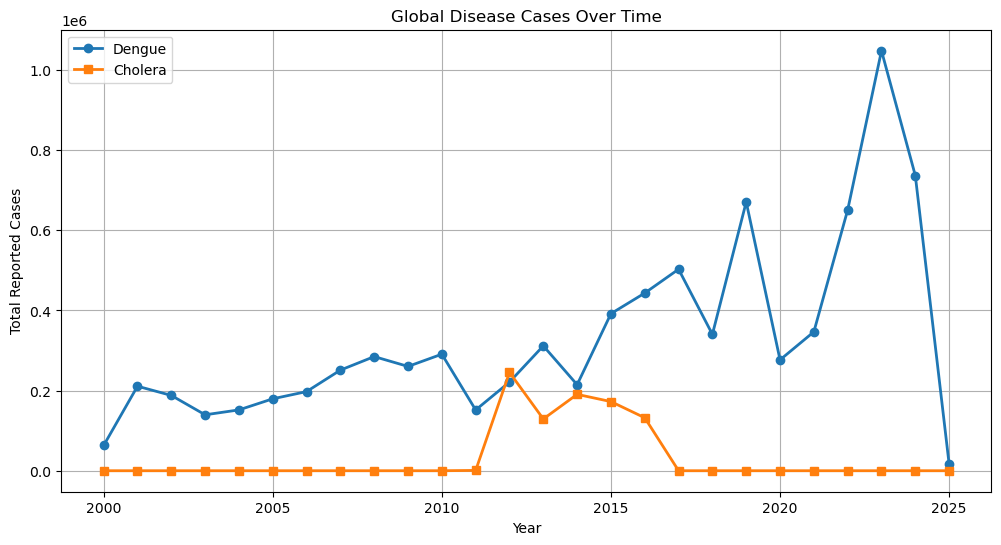

In [4]:
# Time Series of global cases
yearly_totals = master_df.groupby('year')[['dengue_cases', 'cholera_cases']].sum()

plt.figure(figsize=(12, 6))
plt.plot(yearly_totals.index, yearly_totals['dengue_cases'], marker='o', label='Dengue', linewidth=2)
plt.plot(yearly_totals.index, yearly_totals['cholera_cases'], marker='s', label='Cholera', linewidth=2)
plt.title('Global Disease Cases Over Time')
plt.xlabel('Year')
plt.ylabel('Total Reported Cases')
plt.legend()
plt.grid(True)
plt.show()


In [5]:
import warnings
warnings.filterwarnings('ignore')

# Load world map from geopandas
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Calculate total cases per country for mapping
map_data = master_df.groupby('country_code')[['dengue_cases', 'cholera_cases']].sum().reset_index()

# Merge map data with geometries
world_data = world.merge(map_data, how='left', left_on='iso_a3', right_on='country_code')
world_data['dengue_cases'] = world_data['dengue_cases'].fillna(0)
world_data['cholera_cases'] = world_data['cholera_cases'].fillna(0)

# Create a base map using Folium
m = folium.Map(location=[20, 0], zoom_start=2, tiles='cartodb positron')

# Add Dengue Choropleth
folium.Choropleth(
    geo_data=world,
    name='Dengue Cases',
    data=world_data,
    columns=['iso_a3', 'dengue_cases'],
    key_on='feature.properties.iso_a3',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Total Dengue Cases'
).add_to(m)

# Add Cholera Choropleth (can toggle in layer control)
folium.Choropleth(
    geo_data=world,
    name='Cholera Cases',
    data=world_data,
    columns=['iso_a3', 'cholera_cases'],
    key_on='feature.properties.iso_a3',
    fill_color='PuBu',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Total Cholera Cases'
).add_to(m)

folium.LayerControl().add_to(m)

# Display the map
m


NameError: name 'gpd' is not defined